# 02 — Network Building

This notebook walks through the full graph construction pipeline:
- Load the saved `RedditGraphBundle`
- Inspect G_user properties
- Giant component analysis
- Degree distribution
- Node attribute inspection

In [8]:
import sys
sys.path.insert(0, "../src")

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

from reddit_polarization.graphs.build_graphs import RedditGraphBundle

sns.set_theme(style="whitegrid", font_scale=1.1)
OUT = Path("../results/figures")
OUT.mkdir(parents=True, exist_ok=True)

COLORS = {"left":"#4e79a7","right":"#e15759","general":"#76b7b2",
          "non_political":"#bab0ac","mixed":"#f28e2b","unknown":"#d3d3d3"}
POL = {"left", "right"}

## 2.1 Load bundle and inspect

In [9]:
bundle = RedditGraphBundle.load("../data/processed/bundle.pkl")
G      = bundle.G_user

print(bundle.summary())
print(f"\nIs directed  : {G.is_directed()}")
print(f"Self-loops    : {nx.number_of_selfloops(G)}")
print(f"Density       : {nx.density(G):.8f}")

label_dist = Counter(d.get("ideology_label","unknown") for _, d in G.nodes(data=True))
print(f"\nNode ideology distribution:")
for k, v in sorted(label_dist.items(), key=lambda x: -x[1]):
    print(f"  {k:<20} {v:>8,}")

G_user : 1150632 nodes, 3000000 edges
G_bip  : 0 nodes, 0 edges

Is directed  : True
Self-loops    : 0
Density       : 0.00000227

Node ideology distribution:
  non_political         753,716
  unknown               375,516
  right                   7,161
  left                    7,011
  general                 6,785
  mixed                     443


## 2.2 Connected components

Weakly connected components : 67,258
Giant component size        : 999,794 (86.9%)
2nd largest component       : 100
Components with 1 node      : 0


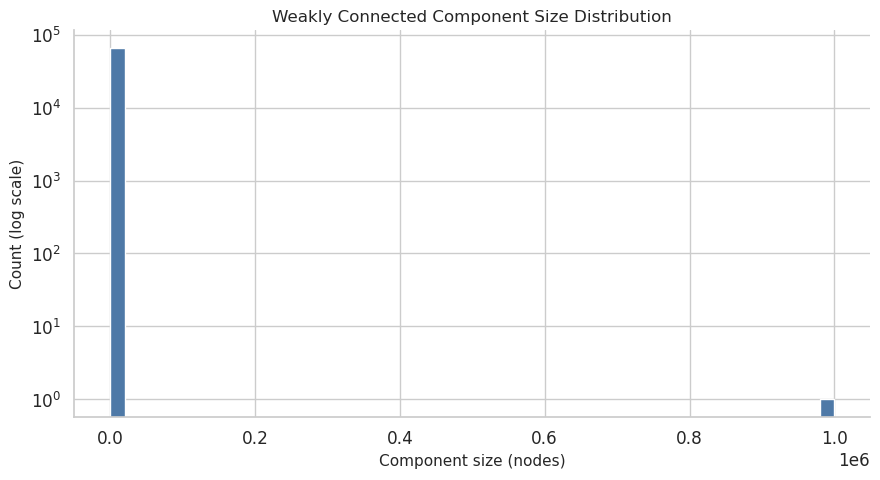

In [10]:
wccs  = list(nx.weakly_connected_components(G))
sizes = sorted([len(c) for c in wccs], reverse=True)

print(f"Weakly connected components : {len(wccs):,}")
print(f"Giant component size        : {sizes[0]:,} ({sizes[0]/G.number_of_nodes()*100:.1f}%)")
print(f"2nd largest component       : {sizes[1]:,}")
print(f"Components with 1 node      : {sum(1 for s in sizes if s==1):,}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sizes, bins=50, color="#4e79a7", edgecolor="white", log=True)
ax.set_xlabel("Component size (nodes)", fontsize=11)
ax.set_ylabel("Count (log scale)", fontsize=11)
ax.set_title("Weakly Connected Component Size Distribution", fontsize=12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb02_components.png", dpi=130, bbox_inches="tight")
plt.show()

## 2.3 Degree distribution — full graph

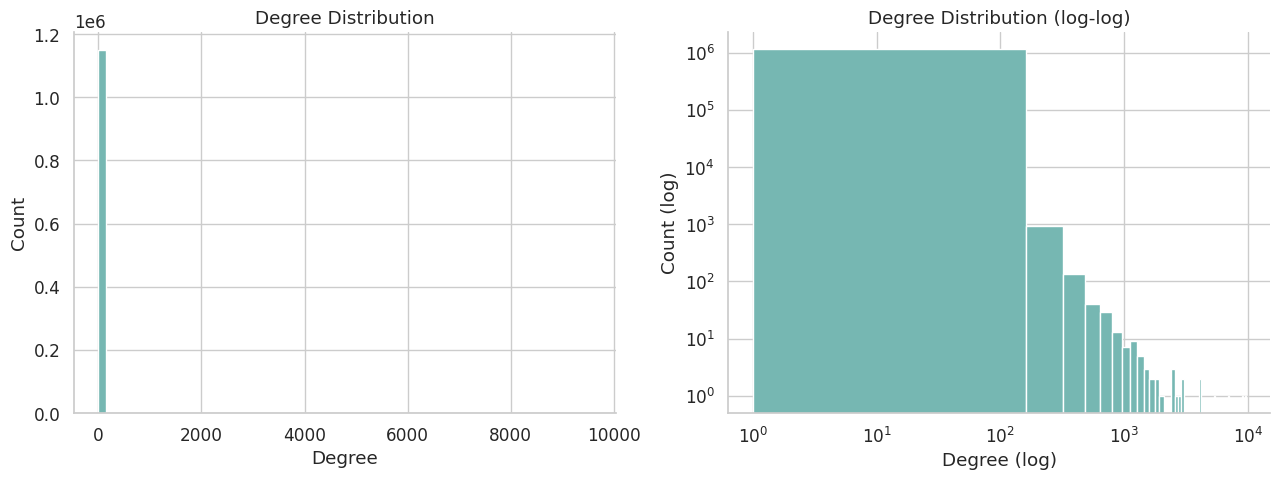

Min degree    : 1
Max degree    : 9561
Mean degree   : 5.21
Median degree : 2


In [11]:
degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(degrees, bins=60, color="#76b7b2", edgecolor="white")
axes[0].set_xlabel("Degree"); axes[0].set_ylabel("Count")
axes[0].set_title("Degree Distribution")
axes[0].spines[["top","right"]].set_visible(False)

axes[1].hist([d for d in degrees if d > 0], bins=60,
             color="#76b7b2", edgecolor="white")
axes[1].set_yscale("log"); axes[1].set_xscale("log")
axes[1].set_xlabel("Degree (log)"); axes[1].set_ylabel("Count (log)")
axes[1].set_title("Degree Distribution (log-log)")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT / "nb02_degree_dist.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Min degree    : {min(degrees)}")
print(f"Max degree    : {max(degrees)}")
print(f"Mean degree   : {np.mean(degrees):.2f}")
print(f"Median degree : {np.median(degrees):.0f}")

## 2.4 Political subgraph construction

Political subgraph: 14,172 nodes, 21,310 edges
Density           : 0.000106


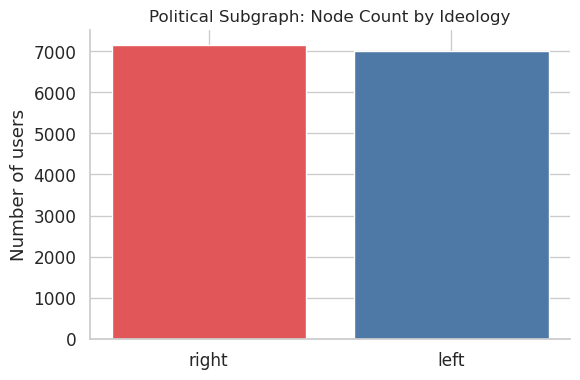

In [12]:
pol_nodes = [n for n, d in G.nodes(data=True) if d.get("ideology_label") in POL]
H = G.subgraph(pol_nodes).copy()

print(f"Political subgraph: {H.number_of_nodes():,} nodes, {H.number_of_edges():,} edges")
print(f"Density           : {nx.density(H):.6f}")

label_counts = Counter(d.get("ideology_label") for _, d in H.nodes(data=True))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(label_counts.keys(), label_counts.values(),
       color=[COLORS[k] for k in label_counts.keys()], edgecolor="white")
ax.set_title("Political Subgraph: Node Count by Ideology", fontsize=12)
ax.set_ylabel("Number of users")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb02_pol_subgraph_labels.png", dpi=130, bbox_inches="tight")
plt.show()

## 2.5 Network visualisation — political subgraph sample

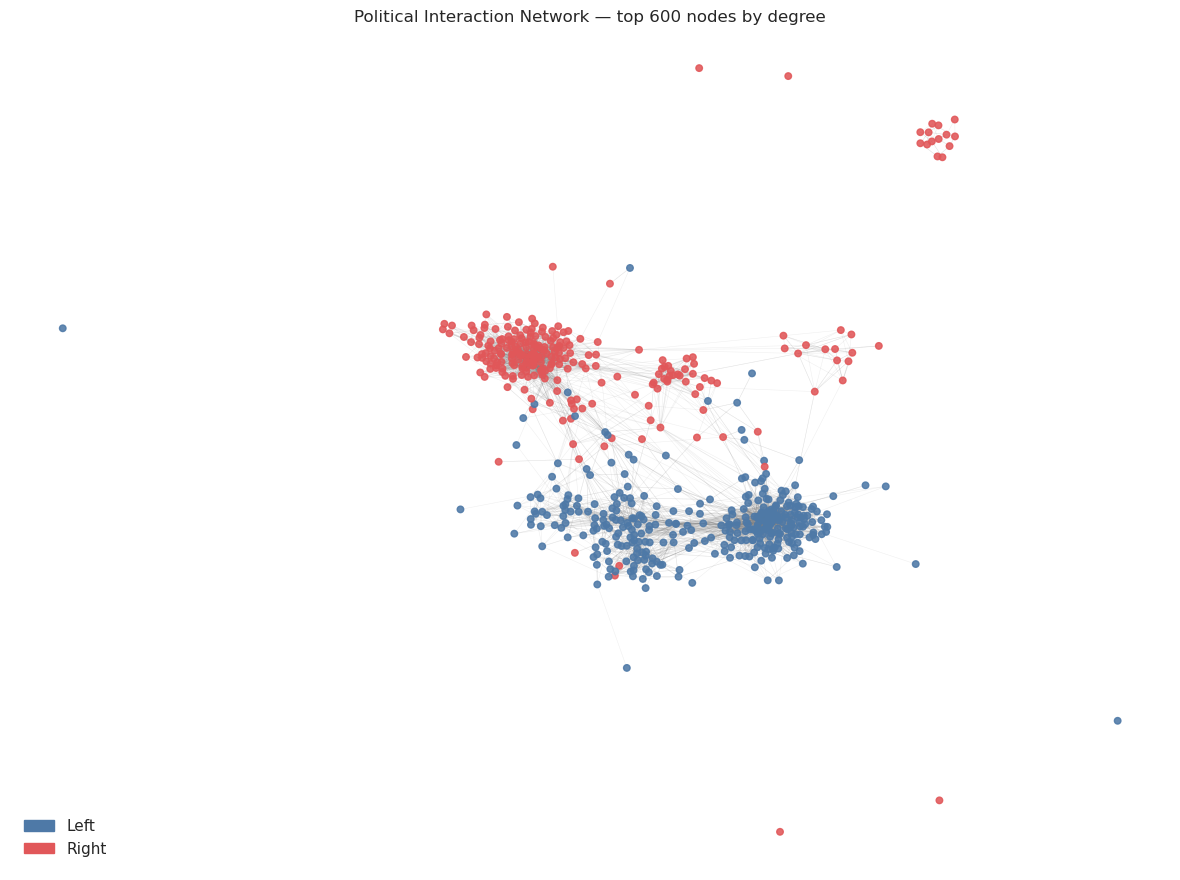

In [13]:
top_nodes  = sorted(H.nodes(), key=lambda n: H.degree(n), reverse=True)[:600]
S          = H.subgraph(top_nodes).copy()
pos        = nx.spring_layout(S, seed=42, k=0.45)
node_colors= [COLORS.get(S.nodes[n].get("ideology_label","unknown"), "#d3d3d3") for n in S.nodes()]

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(S, pos, ax=ax, alpha=0.12, width=0.4, edge_color="gray", arrows=False)
nx.draw_networkx_nodes(S, pos, ax=ax, node_color=node_colors, node_size=22, alpha=0.88)
patches = [mpatches.Patch(color=COLORS["left"], label="Left"),
           mpatches.Patch(color=COLORS["right"], label="Right")]
ax.legend(handles=patches, loc="lower left", frameon=False, fontsize=11)
ax.set_title("Political Interaction Network — top 600 nodes by degree", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUT / "nb02_network.png", dpi=130, bbox_inches="tight")
plt.show()

## 2.6 Edge weight distribution

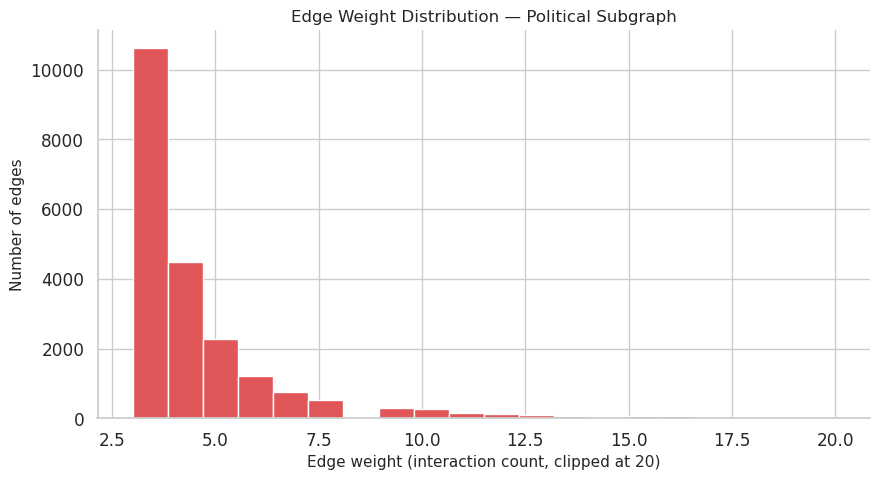

Total edges       : 21,310
Mean weight       : 4.66
Median weight     : 4
Edges weight=1    : 0 (0.0%)
Edges weight>5    : 3,945


In [14]:
weights = [d.get("weight", 1) for _, _, d in H.edges(data=True)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist([w for w in weights if w <= 20], bins=20,
        color="#e15759", edgecolor="white")
ax.set_xlabel("Edge weight (interaction count, clipped at 20)", fontsize=11)
ax.set_ylabel("Number of edges", fontsize=11)
ax.set_title("Edge Weight Distribution — Political Subgraph", fontsize=12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb02_edge_weights.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Total edges       : {len(weights):,}")
print(f"Mean weight       : {np.mean(weights):.2f}")
print(f"Median weight     : {np.median(weights):.0f}")
print(f"Edges weight=1    : {sum(1 for w in weights if w==1):,} ({sum(1 for w in weights if w==1)/len(weights)*100:.1f}%)")
print(f"Edges weight>5    : {sum(1 for w in weights if w>5):,}")